In [5]:
import torch 
import torch.nn as nn

class GMSKAutoEncoder(nn.Module):
    def __init__(self):
        super(GMSKAutoEncoder, self).__init__()

        # Encoder : Compresses noisy I & Q stream into features
        self.encoder = nn.Sequential(
            # Input shape: (batch_size, 2, signal_length)
            nn.Conv1d(2, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        # Decoder : Reconstructs clean I & Q stream from features
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.Conv1d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(8, 2, kernel_size=3, padding=1), # Output shape: (batch_size, 2, signal_length)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    
    def summary(self, input_size = (2, 2048)):
        from torchsummary import summary
        summary(self, input_size=input_size)  

In [6]:
import torch.optim as optim
from pathlib import Path
import numpy as np

data_path = Path.cwd().parent / "Data"

# Load Data
X = torch.from_numpy(np.load(data_path / "X_noisy.npy")).float()  # Noisy signals
Y = torch.from_numpy(np.load(data_path / "Y_clean.npy")).float()  # Clean signals

In [7]:
# Setup model, loss & optimizer
model = GMSKAutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50

model.summary()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1             [-1, 16, 2048]             112
              ReLU-2             [-1, 16, 2048]               0
            Conv1d-3             [-1, 32, 2048]           1,568
              ReLU-4             [-1, 32, 2048]               0
         MaxPool1d-5             [-1, 32, 1024]               0
   ConvTranspose1d-6             [-1, 16, 2048]           1,040
              ReLU-7             [-1, 16, 2048]               0
            Conv1d-8              [-1, 8, 2048]             392
              ReLU-9              [-1, 8, 2048]               0
           Conv1d-10              [-1, 2, 2048]              50
Total params: 3,162
Trainable params: 3,162
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.02
Forward/backward pass size (MB): 2.53
Params size (MB): 0.01
Estimated Total

In [8]:
# Training Loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, Y)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

save_path = Path.cwd().parent / "weights"
# Save the trained model
torch.save(model.state_dict(), save_path / "gmsk_denoiser.pth")

Epoch 0, Loss: 0.5282711982727051
Epoch 10, Loss: 0.4783959686756134
Epoch 20, Loss: 0.4443983733654022
Epoch 30, Loss: 0.39252516627311707
Epoch 40, Loss: 0.3418354392051697


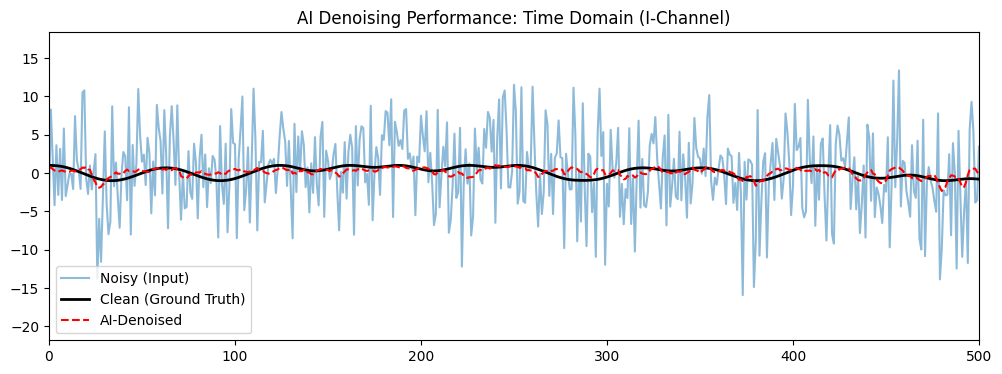

In [9]:
import matplotlib.pyplot as plt

# 1. Select a high-noise sample (e.g., SNR = 0dB)
sample_idx = 0 
noisy_input = X[sample_idx:sample_idx+1] # Shape: (1, 2, Length)

# 2. Run through the AI
model.eval()
with torch.no_grad():
    denoised_output = model(noisy_input).squeeze(0).numpy()

# 3. Plot I-channel comparison
plt.figure(figsize=(12, 4))
plt.plot(noisy_input[0, 0, :].numpy(), label='Noisy (Input)', alpha=0.5)
plt.plot(Y[sample_idx, 0, :].numpy(), label='Clean (Ground Truth)', color='black', lw=2)
plt.plot(denoised_output[0, :], label='AI-Denoised', color='red', linestyle='--')
plt.xlim(0, 500)
plt.title("AI Denoising Performance: Time Domain (I-Channel)")
plt.legend()
plt.show()

C:\Users\charl\OneDrive\Bureau\Cubesat-Radioastronomie\src\modulation.py:71: SyntaxWarning: invalid escape sequence '\p'
  axs[0,2].set_title('$I(t)cos(2 \pi f_c t)$')
C:\Users\charl\OneDrive\Bureau\Cubesat-Radioastronomie\src\modulation.py:74: SyntaxWarning: invalid escape sequence '\p'
  axs[0,3].set_title('$Q(t)sin(2 \pi f_c t)$')
C:\Users\charl\OneDrive\Bureau\Cubesat-Radioastronomie\src\modulation.py:79: SyntaxWarning: invalid escape sequence '\p'
  axs[1,1].set_title('$\phi(t)$')


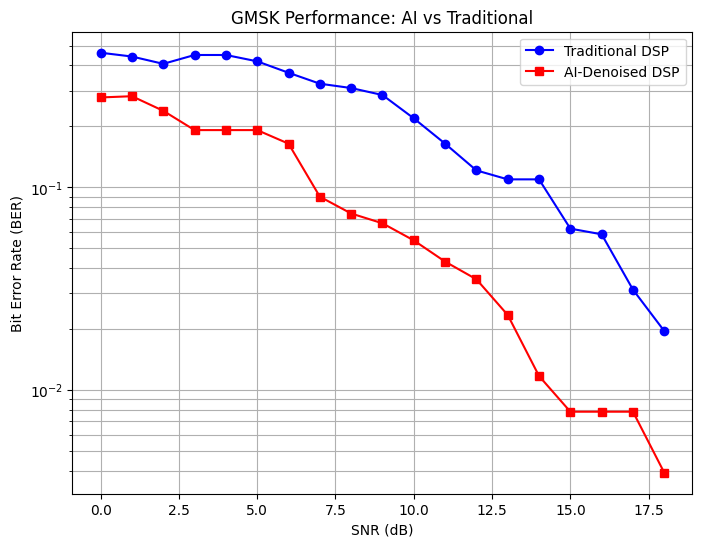

In [10]:
from src.demodulation import gmsk_demod
from src.test_gen import generate_test_signal
snr_range = np.arange(0, 19)  # SNRs from 0dB to 19dB
L = 8  # Samples per symbol
fc = 146e6  # Carrier frequency

ber_traditional = []
ber_ai_assisted = []

model.eval()

for snr in snr_range:
    # 1. Generate test data for this specific SNR
    # (Assuming you have a helper to generate bits and noisy signals)
    bits, s_noisy, s_clean = generate_test_signal(snr, L, fc)
    
    # --- Traditional Path ---
    bits_trad = gmsk_demod(s_noisy, L)
    err_trad = np.sum(bits != bits_trad) / len(bits)
    ber_traditional.append(err_trad)
    
    # --- AI Path ---
    # Prepare for model: (1, 2, Length)
    input_tensor = torch.from_numpy(np.vstack((s_noisy.real, s_noisy.imag))).float().unsqueeze(0)
    with torch.no_grad():
        denoised_iq_raw = model(input_tensor).squeeze(0).numpy()
    
    # Reconstruct complex signal from AI output
    s_denoised = denoised_iq_raw[0, :] + 1j * denoised_iq_raw[1, :]
    
    bits_ai = gmsk_demod(s_denoised, L)
    err_ai = np.sum(bits != bits_ai) / len(bits)
    ber_ai_assisted.append(err_ai)

# Plotting the Waterfall Curve
plt.figure(figsize=(8, 6))
plt.semilogy(snr_range, ber_traditional, 'b-o', label='Traditional DSP')
plt.semilogy(snr_range, ber_ai_assisted, 'r-s', label='AI-Denoised DSP')
plt.grid(True, which='both')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('GMSK Performance: AI vs Traditional')
plt.legend()
plt.show()

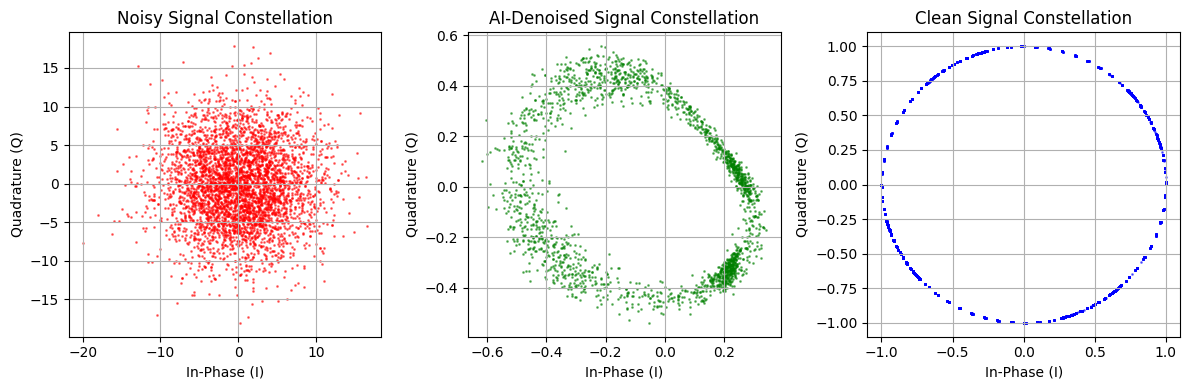

In [17]:
i_noisy = noisy_input[sample_idx, 0, :].numpy()
q_noisy = noisy_input[sample_idx, 1, :].numpy()

i_clean = Y[sample_idx, 0, :].numpy()
q_clean = Y[sample_idx, 1, :].numpy()

i_denoised = denoised_iq_raw[0, :]
q_denoised = denoised_iq_raw[1, :]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.scatter(i_noisy, q_noisy, s=1, alpha=0.5, color = 'r')
ax1.set_title('Noisy Signal Constellation')
ax1.set_xlabel('In-Phase (I)')
ax1.set_ylabel('Quadrature (Q)')
ax1.grid(True)

ax2.scatter(i_denoised, q_denoised, s=1, alpha=0.5, color = 'g')
ax2.set_title('AI-Denoised Signal Constellation')
ax2.set_xlabel('In-Phase (I)')
ax2.set_ylabel('Quadrature (Q)')
ax2.grid(True)

ax3.scatter(i_clean, q_clean, s=1, alpha=0.5, color = 'b')
ax3.set_title('Clean Signal Constellation')
ax3.set_xlabel('In-Phase (I)')
ax3.set_ylabel('Quadrature (Q)')
ax3.grid(True)

plt.tight_layout()
plt.show()